In [1]:
# -*- coding: utf-8 -*-
"""vpr_dinov2_v5_AnaModelEgitimi.ipynb

V5 ana deney:
- DINOv2 ViT-B/14 backbone
- CLS token pooling
- Son 4 transformer block + norm + projection head fine-tuning
- Guclu domain augmentation
- Telefon fotograflari egitime girmez; Notebook 4 sadece cross-source testtir.
"""

# ============================================================
# Hucre 1: Kurulum, Import ve Konfigurasyon
# ============================================================
!pip install faiss-cpu folium pytorch-metric-learning scikit-learn -q
print("Kurulum tamamlandi.")

import os, json, random, zipfile, shutil, math, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from PIL import Image, ImageOps
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from pytorch_metric_learning import losses, miners
from pytorch_metric_learning.samplers import MPerClassSampler
from sklearn.preprocessing import LabelEncoder

import faiss
import folium

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

# Drive / data
DRIVE_ZIP  = "/content/drive/My Drive/kirsehir_data.zip"
LOCAL_ROOT = "/content/kirsehir_data"
OUTPUT_DIR = "/content/drive/My Drive/Kirsehir_VPR_DINOv2_v5_Final"

# Model
MODEL_NAME = "dinov2_vitb14"
POOLING = "cls"
OUTFEATURES = 512
IMG_SIZE = 518
UNFREEZE_LAST_N_BLOCKS = 4

# Training - Colab G4 96GB VRAM Base profil.
# BATCH_SIZE=128, m=4 sampler ile batch basina 32 farkli nokta verir;
# GRAD_ACCUM_STEPS=1 ile gercek batch 128 kullanilir.
# 96 batch yaklasik 20GB kullandigi icin 128 rahat baslangic; OOM olursa 96/64'e don.
BATCH_SIZE = 128
GRAD_ACCUM_STEPS = 1
EFFECTIVE_BATCH_SIZE = BATCH_SIZE * GRAD_ACCUM_STEPS
EPOCHS = 15
PATIENCE = 4
NUM_WORKERS = 4
BACKBONE_LR = 5e-6
HEAD_LR = 8e-5
WEIGHT_DECAY = 1e-4
MAX_GRAD_NORM = 1.0
USE_AMP = torch.cuda.is_available()

# Evaluation
EVAL_BATCH_SIZE = 256
TOP_K = 20
GPS_THRESHOLDS = [25, 50, 100, 500]
GRID_SIZE = 0.002

# Artifacts
BEST_MODEL_NAME = "dinov2_kirsehir_v5_vitb14_cls_domainaug_best.pth"
LAST_MODEL_NAME = "dinov2_kirsehir_v5_vitb14_cls_domainaug_last.pth"
TEST_FAISS_NAME = "faiss_index_v5_test.bin"
TEST_META_NAME = "db_meta_v5_test.json"
ALL_FAISS_NAME = "faiss_index_v5_all.bin"
ALL_META_NAME = "db_meta_v5_all.json"
SAME_SOURCE_METRICS_NAME = "v5_same_source_metrics.json"
TRAIN_HISTORY_NAME = "v5_training_history.json"

BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, BEST_MODEL_NAME)
LAST_MODEL_PATH = os.path.join(OUTPUT_DIR, LAST_MODEL_NAME)
TEST_FAISS_PATH = os.path.join(OUTPUT_DIR, TEST_FAISS_NAME)
TEST_META_PATH = os.path.join(OUTPUT_DIR, TEST_META_NAME)
ALL_FAISS_PATH = os.path.join(OUTPUT_DIR, ALL_FAISS_NAME)
ALL_META_PATH = os.path.join(OUTPUT_DIR, ALL_META_NAME)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Cihaz: {DEVICE}")
print(f"Model: {MODEL_NAME} | Pooling: {POOLING} | Image: {IMG_SIZE}")
print(f"Batch: {BATCH_SIZE} x accum {GRAD_ACCUM_STEPS} = {EFFECTIVE_BATCH_SIZE}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.8/127.8 kB 24.3 MB/s eta 0:00:00
Kurulum tamamlandi.
Cihaz: cuda
Model: dinov2_vitb14 | Pooling: cls | Image: 518
Batch: 128 x accum 1 = 128


In [2]:
# ============================================================
# Hucre 2: Drive Baglantisi, Veri Yukleme ve Split
# ============================================================
from google.colab import drive
drive.mount("/content/drive")
os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.exists(LOCAL_ROOT):
    local_zip = "/content/kirsehir_data.zip"
    print("Veri seti Drive zip dosyasindan aciliyor...")
    shutil.copy2(DRIVE_ZIP, local_zip)
    with zipfile.ZipFile(local_zip, "r") as zf:
        zf.extractall(LOCAL_ROOT)
    os.remove(local_zip)
else:
    print(f"Veri seti zaten mevcut: {LOCAL_ROOT}")

entries = os.listdir(LOCAL_ROOT)
if len(entries) == 1 and os.path.isdir(os.path.join(LOCAL_ROOT, entries[0])):
    LOCAL_ROOT = os.path.join(LOCAL_ROOT, entries[0])

def open_rgb_image(path):
    img = Image.open(path)
    img = ImageOps.exif_transpose(img)
    return img.convert("RGB")

def extract_lat_lon_heading(filepath):
    basename = os.path.basename(filepath)
    stem = os.path.splitext(basename)[0]
    parts = stem.split("_")
    try:
        lat = float(parts[0])
        lon = float(parts[1])
        heading = float(parts[2].replace("h", "")) if len(parts) > 2 else 0.0
        return lat, lon, heading
    except Exception:
        return None, None, None

all_images = []
for street_name in sorted(os.listdir(LOCAL_ROOT)):
    street_path = os.path.join(LOCAL_ROOT, street_name)
    if not os.path.isdir(street_path) or street_name == "model":
        continue
    for fname in sorted(os.listdir(street_path)):
        if not fname.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
            continue
        fpath = os.path.join(street_path, fname)
        lat, lon, heading = extract_lat_lon_heading(fpath)
        if lat is None:
            continue
        all_images.append({
            "filepath": fpath,
            "street": street_name,
            "lat": float(lat),
            "lon": float(lon),
            "heading": float(heading),
            "point_id": f"{lat:.6f}_{lon:.6f}",
            "block_id": f"{int(lat / GRID_SIZE)}_{int(lon / GRID_SIZE)}",
        })

df_all = pd.DataFrame(all_images).sort_values(["point_id", "heading"]).reset_index(drop=True)
if len(df_all) == 0:
    raise RuntimeError("Veri setinde okunabilir gorsel bulunamadi.")

# Ayni kaynak test icin v4 ile ayni mantik: sehir bloklarini train/test ayir.
unique_blocks = df_all["block_id"].unique().tolist()
random.shuffle(unique_blocks)
n_train_blocks = int(len(unique_blocks) * 0.70)
train_blocks = set(unique_blocks[:n_train_blocks])
test_blocks = set(unique_blocks[n_train_blocks:])

df_train = df_all[df_all["block_id"].isin(train_blocks)].copy().reset_index(drop=True)
df_test = df_all[df_all["block_id"].isin(test_blocks)].copy().reset_index(drop=True)

# Metric learning sinifi: nokta id. N/S/E/W ayni sinifta kalir.
df_train["class_id"] = df_train["point_id"]
le = LabelEncoder()
df_train["label"] = le.fit_transform(df_train["class_id"])

# Testte her noktadan bir yon query, kalan yonler DB.
point_counts = df_test["point_id"].value_counts()
valid_points = point_counts[point_counts >= 2].index
df_test = df_test[df_test["point_id"].isin(valid_points)].copy().reset_index(drop=True)
df_query = df_test.groupby("point_id").tail(1).reset_index(drop=True)
query_filepaths = set(df_query["filepath"])
df_db = df_test[~df_test["filepath"].isin(query_filepaths)].copy().reset_index(drop=True)

print(f"Toplam gorsel       : {len(df_all):,}")
print(f"Train gorsel        : {len(df_train):,}")
print(f"Same-source DB      : {len(df_db):,}")
print(f"Same-source query   : {len(df_query):,}")
print(f"Train nokta sinifi  : {df_train['label'].nunique():,}")
print(f"Sokak sayisi        : {df_all['street'].nunique():,}")

Mounted at /content/drive
Veri seti Drive zip dosyasindan aciliyor...
Toplam gorsel       : 26,220
Train gorsel        : 18,140
Same-source DB      : 6,060
Same-source query   : 2,020
Train nokta sinifi  : 4,535
Sokak sayisi        : 654


In [3]:
# ============================================================
# Hucre 3: Transformlar, Dataset ve Metric-Learning Dataloader
# ============================================================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.55, 1.0),
        ratio=(0.75, 1.33),
        interpolation=T.InterpolationMode.BICUBIC,
    ),
    T.RandomApply([
        T.RandomPerspective(
            distortion_scale=0.18,
            p=1.0,
            interpolation=T.InterpolationMode.BICUBIC,
            fill=0,
        )
    ], p=0.35),
    T.RandomRotation(
        degrees=7,
        interpolation=T.InterpolationMode.BICUBIC,
        fill=0,
    ),
    T.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.30, hue=0.04),
    T.RandomAutocontrast(p=0.25),
    T.RandomApply([T.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5))], p=0.20),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class VPRTrainDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = open_rgb_image(row["filepath"])
        return self.transform(img), int(row["label"])

class VPREvalDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = open_rgb_image(row["filepath"])
        return self.transform(img), int(idx)

train_dataset = VPRTrainDataset(df_train, train_transform)

# m=4: ayni GSV noktasinin farkli yonleri ayni batch icinde pozitif olur.
sampler = MPerClassSampler(
    df_train["label"].values,
    m=4,
    batch_size=BATCH_SIZE,
    length_before_new_iter=len(df_train),
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
)

print(f"Dataloader hazir. Epoch batch sayisi: {len(train_loader):,}")

Dataloader hazir. Epoch batch sayisi: 141


In [4]:
# ============================================================
# Hucre 4: ViT-B/CLS Model, Egitim ve Epoch Sonu Degerlendirme
# ============================================================
class VPRDINOv2CLS(nn.Module):
    def __init__(self, backbone_name, out_dim, unfreeze_last_n=4):
        super().__init__()
        self.backbone = torch.hub.load("facebookresearch/dinov2", backbone_name, verbose=False)
        embed_dim = self.backbone.embed_dim

        for param in self.backbone.parameters():
            param.requires_grad = False

        n_blocks = len(getattr(self.backbone, "blocks", []))
        trainable_blocks = set(range(max(0, n_blocks - unfreeze_last_n), n_blocks))

        for name, param in self.backbone.named_parameters():
            if name.startswith("norm"):
                param.requires_grad = True
            elif name.startswith("blocks."):
                parts = name.split(".")
                if len(parts) > 1 and parts[1].isdigit() and int(parts[1]) in trainable_blocks:
                    param.requires_grad = True

        self.head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.10),
            nn.Linear(embed_dim, out_dim),
        )

        print(f"Backbone block sayisi: {n_blocks}")
        print(f"Egitime acik son blocklar: {sorted(trainable_blocks)}")
        print(f"Embed dim: {embed_dim} -> descriptor dim: {out_dim}")

    def forward(self, x):
        ret = self.backbone.forward_features(x)
        x = ret["x_norm_clstoken"]
        x = self.head(x)
        return nn.functional.normalize(x, p=2, dim=1)

def count_trainable_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def haversine(lat1, lon1, lat2, lon2):
    R = 6371000.0
    p1 = math.radians(float(lat1))
    p2 = math.radians(float(lat2))
    dp = math.radians(float(lat2) - float(lat1))
    dl = math.radians(float(lon2) - float(lon1))
    a = math.sin(dp / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

@torch.no_grad()
def extract_embeddings(model, df, transform, batch_size, device, desc="Embeddings"):
    loader = DataLoader(
        VPREvalDataset(df, transform),
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )
    model.eval()
    all_embs = []
    for imgs, _ in tqdm(loader, desc=desc):
        imgs = imgs.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            embs = model(imgs)
        all_embs.append(embs.detach().cpu().numpy().astype(np.float32))
    return np.concatenate(all_embs, axis=0)

def build_faiss_index(embeddings):
    emb = embeddings.astype(np.float32).copy()
    faiss.normalize_L2(emb)
    index = faiss.IndexFlatIP(emb.shape[1])
    index.add(emb)
    return index, emb

def evaluate_top1(model, df_db, df_query, transform, batch_size, device, top_k=20, desc_prefix="Eval"):
    db_embeddings = extract_embeddings(model, df_db, transform, batch_size, device, f"{desc_prefix} DB")
    query_embeddings = extract_embeddings(model, df_query, transform, batch_size, device, f"{desc_prefix} Query")

    index, db_embeddings_norm = build_faiss_index(db_embeddings)
    query_norm = query_embeddings.astype(np.float32).copy()
    faiss.normalize_L2(query_norm)

    search_k = min(top_k, index.ntotal)
    sims, idxs = index.search(query_norm, search_k)
    db_meta = df_db[["filepath", "street", "lat", "lon", "heading", "point_id"]].to_dict("records")

    errors = []
    street_correct = 0
    street_topk = {5: 0, 10: 0, 20: 0}
    per_query = []

    for i, q_row in df_query.reset_index(drop=True).iterrows():
        best = db_meta[int(idxs[i, 0])]
        err = haversine(q_row["lat"], q_row["lon"], best["lat"], best["lon"])
        errors.append(err)

        if best["street"] == q_row["street"]:
            street_correct += 1

        top_streets = [db_meta[int(j)]["street"] for j in idxs[i]]
        for k in street_topk:
            if q_row["street"] in top_streets[:min(k, len(top_streets))]:
                street_topk[k] += 1

        per_query.append({
            "query_filepath": q_row["filepath"],
            "gt_street": q_row["street"],
            "gt_lat": float(q_row["lat"]),
            "gt_lon": float(q_row["lon"]),
            "pred_street": best["street"],
            "pred_lat": float(best["lat"]),
            "pred_lon": float(best["lon"]),
            "pred_filepath": best["filepath"],
            "similarity": float(sims[i, 0]),
            "error_m": float(err),
            "correct_street_top1": bool(best["street"] == q_row["street"]),
            "correct_street_top5": bool(q_row["street"] in top_streets[:min(5, len(top_streets))]),
            "correct_street_top10": bool(q_row["street"] in top_streets[:min(10, len(top_streets))]),
            "correct_street_top20": bool(q_row["street"] in top_streets[:min(20, len(top_streets))]),
        })

    errors = np.array(errors, dtype=np.float32)
    n = max(1, len(errors))
    metrics = {
        "num_db": int(len(df_db)),
        "num_query": int(len(df_query)),
        "street_accuracy": float(street_correct / n * 100),
        "street_top5_accuracy": float(street_topk[5] / n * 100),
        "street_top10_accuracy": float(street_topk[10] / n * 100),
        "street_top20_accuracy": float(street_topk[20] / n * 100),
        "median_error_m": float(np.median(errors)),
        "mean_error_m": float(np.mean(errors)),
        "r1_25m": float((errors <= 25).mean() * 100),
        "r1_50m": float((errors <= 50).mean() * 100),
        "r1_100m": float((errors <= 100).mean() * 100),
        "r1_500m": float((errors <= 500).mean() * 100),
    }

    return {
        "metrics": metrics,
        "errors": errors,
        "per_query": per_query,
        "index": index,
        "db_meta": db_meta,
        "db_embeddings": db_embeddings,
        "query_embeddings": query_embeddings,
        "db_embeddings_norm": db_embeddings_norm,
        "query_embeddings_norm": query_norm,
        "similarities": sims,
        "indices": idxs,
    }

def print_metrics(metrics, title):
    print(f"\n{'=' * 64}")
    print(title)
    print(f"{'=' * 64}")
    print(f"Sokak Top-1       : {metrics['street_accuracy']:.2f}%")
    print(f"Sokak Top-5/10/20 : {metrics['street_top5_accuracy']:.2f}% / {metrics['street_top10_accuracy']:.2f}% / {metrics['street_top20_accuracy']:.2f}%")
    print(f"Median / Mean     : {metrics['median_error_m']:.1f}m / {metrics['mean_error_m']:.1f}m")
    print(f"R@1 <25/50/100/500m: {metrics['r1_25m']:.2f}% / {metrics['r1_50m']:.2f}% / {metrics['r1_100m']:.2f}% / {metrics['r1_500m']:.2f}%")

model = VPRDINOv2CLS(MODEL_NAME, OUTFEATURES, UNFREEZE_LAST_N_BLOCKS).to(DEVICE)
total_params, trainable_params = count_trainable_params(model)
print(f"Parametre: total={total_params:,} | trainable={trainable_params:,} ({trainable_params / total_params * 100:.2f}%)")

miner = miners.MultiSimilarityMiner(epsilon=0.1)
loss_func = losses.MultiSimilarityLoss(alpha=2, beta=50, base=0.5)

optimizer = optim.AdamW([
    {"params": [p for p in model.backbone.parameters() if p.requires_grad], "lr": BACKBONE_LR},
    {"params": model.head.parameters(), "lr": HEAD_LR},
], weight_decay=WEIGHT_DECAY)

updates_per_epoch = math.ceil(len(train_loader) / GRAD_ACCUM_STEPS)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max(1, updates_per_epoch * EPOCHS),
    eta_min=1e-7,
)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

history = []
best_model_r1 = -1.0
best_model_median = float("inf")
best_stop_r1 = -1.0
best_stop_median = float("inf")
bad_epochs = 0

print("\nFine-tuning basliyor...")
for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad(set_to_none=True)
    epoch_loss = 0.0
    valid_micro_batches = 0
    update_count = 0
    start = time.time()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS}")
    for imgs, labels in pbar:
        imgs = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            embeddings = model(imgs)
            hard_pairs = miner(embeddings, labels)
            loss = loss_func(embeddings, labels, hard_pairs)

        if (not torch.isfinite(loss)) or loss.item() <= 0:
            continue

        scaler.scale(loss / GRAD_ACCUM_STEPS).backward()
        epoch_loss += float(loss.item())
        valid_micro_batches += 1

        if valid_micro_batches % GRAD_ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad],
                MAX_GRAD_NORM,
            )
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()
            update_count += 1

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "upd": update_count,
            "lr": f"{scheduler.get_last_lr()[0]:.1e}",
        })

    if valid_micro_batches % GRAD_ACCUM_STEPS != 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad],
            MAX_GRAD_NORM,
        )
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
        scheduler.step()
        update_count += 1

    avg_loss = epoch_loss / max(1, valid_micro_batches)
    torch.save(model.state_dict(), LAST_MODEL_PATH)

    torch.cuda.empty_cache()
    gc.collect()
    eval_result = evaluate_top1(
        model,
        df_db,
        df_query,
        eval_transform,
        EVAL_BATCH_SIZE,
        DEVICE,
        TOP_K,
        desc_prefix=f"Epoch {epoch + 1}",
    )
    metrics = eval_result["metrics"]
    print_metrics(metrics, f"Epoch {epoch + 1} same-source Top-1 metrikleri")

    improved_for_checkpoint = (
        metrics["r1_100m"] > best_model_r1 + 1e-9 or
        (abs(metrics["r1_100m"] - best_model_r1) <= 1e-9 and metrics["median_error_m"] < best_model_median)
    )
    if improved_for_checkpoint:
        best_model_r1 = metrics["r1_100m"]
        best_model_median = metrics["median_error_m"]
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"Yeni best checkpoint kaydedildi: {BEST_MODEL_PATH}")

    improved_for_stopping = (
        metrics["r1_100m"] > best_stop_r1 + 1e-9 or
        metrics["median_error_m"] < best_stop_median - 1e-9
    )
    if improved_for_stopping:
        best_stop_r1 = max(best_stop_r1, metrics["r1_100m"])
        best_stop_median = min(best_stop_median, metrics["median_error_m"])
        bad_epochs = 0
    else:
        bad_epochs += 1

    epoch_record = {
        "epoch": epoch + 1,
        "avg_loss": float(avg_loss),
        "valid_micro_batches": int(valid_micro_batches),
        "optimizer_updates": int(update_count),
        "duration_min": float((time.time() - start) / 60),
        "bad_epochs": int(bad_epochs),
        **metrics,
    }
    history.append(epoch_record)

    with open(os.path.join(OUTPUT_DIR, TRAIN_HISTORY_NAME), "w", encoding="utf-8") as f:
        json.dump(history, f, ensure_ascii=False, indent=2)

    if bad_epochs >= PATIENCE:
        print(f"Early stopping: {PATIENCE} epoch boyunca R@1<100m veya median iyilesmedi.")
        break

print("\nEgitim tamamlandi.")
print(f"Best model: {BEST_MODEL_PATH}")

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:00<00:00, 395MB/s]


Backbone block sayisi: 12
Egitime acik son blocklar: [8, 9, 10, 11]
Embed dim: 768 -> descriptor dim: 512


...


Epoch 13 same-source Top-1 metrikleri
Sokak Top-1       : 82.52%
Sokak Top-5/10/20 : 96.93% / 98.32% / 99.55%
Median / Mean     : 1.4m / 77.1m
R@1 <25/50/100/500m: 71.53% / 82.13% / 90.15% / 96.39%


Epoch 14/15:   0%|          | 0/141 [00:00<?, ?it/s]/tmp/ipykernel_1983/584267750.py:209: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
Epoch 14 DB:   0%|          | 0/24 [00:00<?, ?it/s]/tmp/ipykernel_1983/584267750.py:69: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
Epoch 14 Query: 100%|██████████| 8/8 [00:05<00:00,  1.39it/s]



Epoch 14 same-source Top-1 metrikleri
Sokak Top-1       : 82.77%
Sokak Top-5/10/20 : 96.88% / 98.47% / 99.65%
Median / Mean     : 1.3m / 78.1m
R@1 <25/50/100/500m: 71.58% / 82.23% / 90.15% / 96.29%


Epoch 15/15:   0%|          | 0/141 [00:00<?, ?it/s]/tmp/ipykernel_1983/584267750.py:209: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
Epoch 15 DB:   0%|          | 0/24 [00:00<?, ?it/s]/tmp/ipykernel_1983/584267750.py:69: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
Epoch 15 Query: 100%|██████████| 8/8 [00:05<00:00,  1.43it/s]



Epoch 15 same-source Top-1 metrikleri
Sokak Top-1       : 82.62%
Sokak Top-5/10/20 : 96.73% / 98.37% / 99.65%
Median / Mean     : 1.3m / 82.8m
R@1 <25/50/100/500m: 71.39% / 82.28% / 89.90% / 96.14%
Early stopping: 4 epoch boyunca R@1<100m veya median iyilesmedi.

Egitim tamamlandi.
Best model: /content/drive/My Drive/Kirsehir_VPR_DINOv2_v5_Final/dinov2_kirsehir_v5_vitb14_cls_domainaug_best.pth


In [5]:
# ============================================================
# Hucre 5: Best Model ile Final Same-Source Degerlendirme ve Test FAISS
# ============================================================
if not os.path.exists(BEST_MODEL_PATH):
    raise FileNotFoundError(f"Best checkpoint bulunamadi: {BEST_MODEL_PATH}")

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()
torch.cuda.empty_cache()
gc.collect()

final_eval = evaluate_top1(
    model,
    df_db,
    df_query,
    eval_transform,
    EVAL_BATCH_SIZE,
    DEVICE,
    TOP_K,
    desc_prefix="Final same-source",
)
final_metrics = final_eval["metrics"]
print_metrics(final_metrics, "V5 Final Same-Source Top-1 Metrikleri")

faiss.write_index(final_eval["index"], TEST_FAISS_PATH)
with open(TEST_META_PATH, "w", encoding="utf-8") as f:
    json.dump(final_eval["db_meta"], f, ensure_ascii=False, indent=2)

np.save(os.path.join(OUTPUT_DIR, "db_embeddings_v5_test.npy"), final_eval["db_embeddings_norm"])
np.save(os.path.join(OUTPUT_DIR, "query_embeddings_v5_test.npy"), final_eval["query_embeddings_norm"])

same_source_report = {
    "model_name": MODEL_NAME,
    "pooling": POOLING,
    "img_size": IMG_SIZE,
    "unfreeze_last_n_blocks": UNFREEZE_LAST_N_BLOCKS,
    "batch_size": BATCH_SIZE,
    "grad_accum_steps": GRAD_ACCUM_STEPS,
    "effective_batch_size": EFFECTIVE_BATCH_SIZE,
    "epochs_planned": EPOCHS,
    "patience": PATIENCE,
    "metrics": final_metrics,
    "v4_reference": {
        "street_accuracy": 74.70,
        "median_error_m": 8.2,
        "r1_100m": 81.24,
    },
    "per_query": final_eval["per_query"],
}

same_source_path = os.path.join(OUTPUT_DIR, SAME_SOURCE_METRICS_NAME)
with open(same_source_path, "w", encoding="utf-8") as f:
    json.dump(same_source_report, f, ensure_ascii=False, indent=2)

print(f"\nTest FAISS kaydedildi: {TEST_FAISS_PATH}")
print(f"Test metadata kaydedildi: {TEST_META_PATH}")
print(f"Same-source rapor kaydedildi: {same_source_path}")

Final same-source DB:   0%|          | 0/24 [00:00<?, ?it/s]/tmp/ipykernel_1983/584267750.py:69: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
Final same-source Query: 100%|██████████| 8/8 [00:05<00:00,  1.40it/s]



V5 Final Same-Source Top-1 Metrikleri
Sokak Top-1       : 82.67%
Sokak Top-5/10/20 : 96.98% / 98.47% / 99.60%
Median / Mean     : 1.1m / 83.5m
R@1 <25/50/100/500m: 71.49% / 82.43% / 90.30% / 96.09%

Test FAISS kaydedildi: /content/drive/My Drive/Kirsehir_VPR_DINOv2_v5_Final/faiss_index_v5_test.bin
Test metadata kaydedildi: /content/drive/My Drive/Kirsehir_VPR_DINOv2_v5_Final/db_meta_v5_test.json
Same-source rapor kaydedildi: /content/drive/My Drive/Kirsehir_VPR_DINOv2_v5_Final/v5_same_source_metrics.json


In [6]:
# ============================================================
# Hucre 6: Tum Gorsellerle Notebook 4 Icin Deployment FAISS
# ============================================================
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()
torch.cuda.empty_cache()
gc.collect()

all_embeddings = extract_embeddings(
    model,
    df_all,
    eval_transform,
    EVAL_BATCH_SIZE,
    DEVICE,
    desc="All-image DB embeddings",
)
all_index, all_embeddings_norm = build_faiss_index(all_embeddings)
all_meta = df_all[["filepath", "street", "lat", "lon", "heading", "point_id"]].to_dict("records")

faiss.write_index(all_index, ALL_FAISS_PATH)
with open(ALL_META_PATH, "w", encoding="utf-8") as f:
    json.dump(all_meta, f, ensure_ascii=False, indent=2)

np.save(os.path.join(OUTPUT_DIR, "all_embeddings_v5.npy"), all_embeddings_norm)

print(f"All-image FAISS kaydedildi: {ALL_FAISS_PATH}")
print(f"All-image metadata kaydedildi: {ALL_META_PATH}")
print("\nNotebook 4 bu dosyalari kullanacak:")
print(f"DRIVE_DIR  = {OUTPUT_DIR}")
print(f"MODEL_PATH = {BEST_MODEL_NAME}")
print(f"FAISS_PATH = {ALL_FAISS_NAME}")
print(f"META_PATH  = {ALL_META_NAME}")

All-image DB embeddings:   0%|          | 0/103 [00:00<?, ?it/s]/tmp/ipykernel_1983/584267750.py:69: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
All-image DB embeddings: 100%|██████████| 103/103 [00:46<00:00,  2.21it/s]


All-image FAISS kaydedildi: /content/drive/My Drive/Kirsehir_VPR_DINOv2_v5_Final/faiss_index_v5_all.bin
All-image metadata kaydedildi: /content/drive/My Drive/Kirsehir_VPR_DINOv2_v5_Final/db_meta_v5_all.json

Notebook 4 bu dosyalari kullanacak:
DRIVE_DIR  = /content/drive/My Drive/Kirsehir_VPR_DINOv2_v5_Final
MODEL_PATH = dinov2_kirsehir_v5_vitb14_cls_domainaug_best.pth
FAISS_PATH = faiss_index_v5_all.bin
META_PATH  = db_meta_v5_all.json


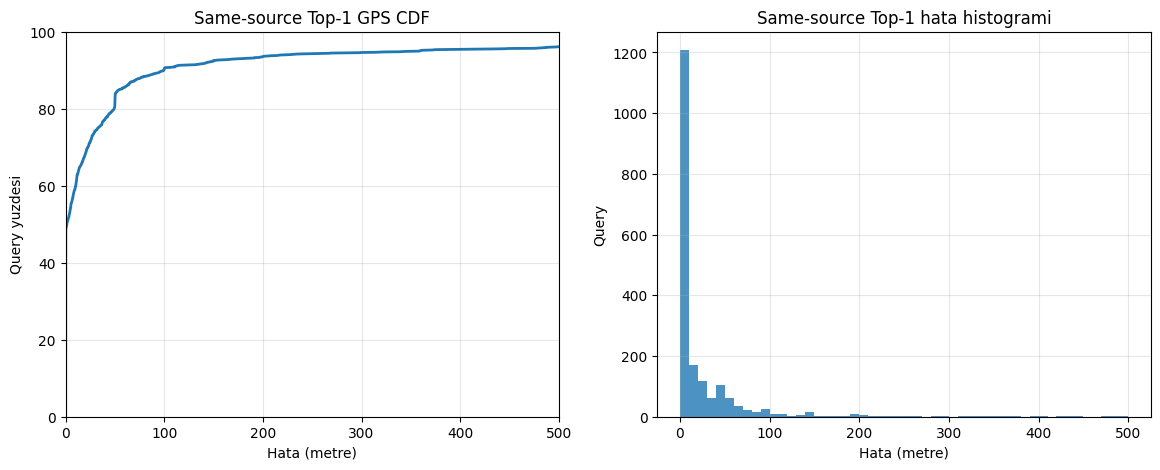

Harita kaydedildi: /content/drive/My Drive/Kirsehir_VPR_DINOv2_v5_Final/v5_same_source_examples_map.html


In [7]:
# ============================================================
# Hucre 7: Same-Source Hata Grafikleri ve Ornek Harita
# ============================================================
errors = final_eval["errors"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sorted_errors = np.sort(errors)
cdf = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors) * 100
axes[0].plot(sorted_errors, cdf, lw=2)
axes[0].set_xlim(0, 500)
axes[0].set_ylim(0, 100)
axes[0].grid(True, alpha=0.3)
axes[0].set_title("Same-source Top-1 GPS CDF")
axes[0].set_xlabel("Hata (metre)")
axes[0].set_ylabel("Query yuzdesi")

axes[1].hist(errors, bins=50, range=(0, 500), alpha=0.8)
axes[1].grid(True, alpha=0.3)
axes[1].set_title("Same-source Top-1 hata histogrami")
axes[1].set_xlabel("Hata (metre)")
axes[1].set_ylabel("Query")
plt.show()

# En iyi / en kotu birkac ornegi haritaya koy.
per_query_df = pd.DataFrame(final_eval["per_query"])
sample_df = pd.concat([
    per_query_df.sort_values("error_m").head(5),
    per_query_df.sort_values("error_m").tail(5),
]).drop_duplicates()

center_lat = float(df_query["lat"].mean())
center_lon = float(df_query["lon"].mean())
m = folium.Map(location=[center_lat, center_lon], zoom_start=13)
for _, row in sample_df.iterrows():
    folium.CircleMarker(
        [row["gt_lat"], row["gt_lon"]],
        radius=4,
        color="green",
        fill=True,
        popup=f"GT: {row['gt_street']}",
    ).add_to(m)
    folium.CircleMarker(
        [row["pred_lat"], row["pred_lon"]],
        radius=4,
        color="red",
        fill=True,
        popup=f"Pred: {row['pred_street']} | {row['error_m']:.1f}m",
    ).add_to(m)
    folium.PolyLine(
        [[row["gt_lat"], row["gt_lon"]], [row["pred_lat"], row["pred_lon"]]],
        color="blue",
        weight=1,
        opacity=0.6,
    ).add_to(m)

map_path = os.path.join(OUTPUT_DIR, "v5_same_source_examples_map.html")
m.save(map_path)
print(f"Harita kaydedildi: {map_path}")
m

In [8]:
# ============================================================
# Hucre 8: Opsiyonel Tek Gorsel Testi
# ============================================================
# Colab'da hizli deneme icin:
# 1) query_path degiskenine bir gorsel yolu ver.
# 2) Bu hucreyi calistir.

query_path = None  # ornek: "/content/drive/My Drive/test.jpg"

if query_path:
    img = open_rgb_image(query_path)
    x = eval_transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad(), torch.cuda.amp.autocast(enabled=USE_AMP):
        emb = model(x).detach().cpu().numpy().astype(np.float32)
    faiss.normalize_L2(emb)
    sims, idxs = all_index.search(emb, 10)
    print("Top-10 aday:")
    for rank, (score, idx) in enumerate(zip(sims[0], idxs[0]), start=1):
        meta = all_meta[int(idx)]
        print(f"{rank:02d}. {meta['street']} | sim={score:.4f} | {meta['lat']:.6f},{meta['lon']:.6f} | {meta['filepath']}")
else:
    print("query_path bos; bu hucre opsiyonel.")

query_path bos; bu hucre opsiyonel.


In [9]:
# ============================================================
# Hucre 9: V5 Cikti Ozeti
# ============================================================
print("V5 ana egitim notebook'u tamamlandi.")
print(f"Best model             : {BEST_MODEL_PATH}")
print(f"Same-source test FAISS : {TEST_FAISS_PATH}")
print(f"Same-source test meta  : {TEST_META_PATH}")
print(f"Notebook 4 all FAISS   : {ALL_FAISS_PATH}")
print(f"Notebook 4 all meta    : {ALL_META_PATH}")
print(f"Same-source metrics    : {os.path.join(OUTPUT_DIR, SAME_SOURCE_METRICS_NAME)}")
print("\nSiradaki adim: Bu notebook'u Colab'da bastan sona calistir; sonra Notebook 4 v5 artifact'leriyle cross-source testi yapacak.")

V5 ana egitim notebook'u tamamlandi.
Best model             : /content/drive/My Drive/Kirsehir_VPR_DINOv2_v5_Final/dinov2_kirsehir_v5_vitb14_cls_domainaug_best.pth
Same-source test FAISS : /content/drive/My Drive/Kirsehir_VPR_DINOv2_v5_Final/faiss_index_v5_test.bin
Same-source test meta  : /content/drive/My Drive/Kirsehir_VPR_DINOv2_v5_Final/db_meta_v5_test.json
Notebook 4 all FAISS   : /content/drive/My Drive/Kirsehir_VPR_DINOv2_v5_Final/faiss_index_v5_all.bin
Notebook 4 all meta    : /content/drive/My Drive/Kirsehir_VPR_DINOv2_v5_Final/db_meta_v5_all.json
Same-source metrics    : /content/drive/My Drive/Kirsehir_VPR_DINOv2_v5_Final/v5_same_source_metrics.json

Siradaki adim: Bu notebook'u Colab'da bastan sona calistir; sonra Notebook 4 v5 artifact'leriyle cross-source testi yapacak.
